In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from pathlib import Path
from collections import defaultdict
import glob

base_path = Path("/content/drive/MyDrive/Jewelry_Project/Jewelry_review_files/")
year_folders = sorted(base_path.glob("year=*"))
# print(year_folders)

total_reviews = 0
reviews_per_year = defaultdict(int)
unique_products = set()
unique_manufacturer = set()
unique_brand = set()
reviews_per_manufacturer = defaultdict(int)
reviews_per_brand = defaultdict(int)

for year_folder in year_folders:
    year = year_folder.name.split("=")[1]
    parquet_files = list(year_folder.glob("*.parquet"))
    for file in parquet_files:
        df = pd.read_parquet(file, columns=["parent_asin", "manufacturer", "brand", "review"])
        unique_products.update(df["parent_asin"].dropna().unique())
        unique_manufacturer.update(df["manufacturer"].dropna().unique())
        unique_brand.update(df["brand"].dropna().unique())

        df_reviews = df.dropna(subset=["review"])
        total_reviews += len(df_reviews)
        reviews_per_year[year] += len(df_reviews)
        counts_manufacturer = df_reviews["manufacturer"].value_counts()
        counts_brand = df_reviews["brand"].value_counts()

        for manufacturer, count in counts_manufacturer.items():
            reviews_per_manufacturer[manufacturer]+=count

        for brand, count in counts_brand.items():
            reviews_per_brand[brand]+=count

print("Total Reviews:", total_reviews)
print("Reviews per year:", dict(reviews_per_year))
print("Total unique products:", len(unique_products))
print("Total unique manufacturers:", len(unique_manufacturer))
reviews_per_manufacturer=pd.Series(reviews_per_manufacturer)
reviews_per_manufacturer.sort_values(ascending=False,inplace=True)
print("Reviews per manufacturer:", reviews_per_manufacturer.head(5))
print("Total unique brands:", len(unique_brand))
reviews_per_brand=pd.Series(reviews_per_brand)
reviews_per_brand.sort_values(ascending=False,inplace=True)
print("Reviews per brand:", reviews_per_brand.head(5))

Total Reviews: 6839120
Reviews per year: {'2002': 3, '2003': 10, '2004': 130, '2005': 363, '2006': 699, '2007': 3314, '2008': 5071, '2009': 6626, '2010': 11867, '2011': 23052, '2012': 59791, '2013': 157787, '2014': 272765, '2015': 413728, '2016': 520207, '2017': 541159, '2018': 653378, '2019': 933186, '2020': 903604, '2021': 1014927, '2022': 913365, '2023': 404088}
Total unique products: 804525
Total unique manufacturers: 44888
Reviews per manufacturer: Amazon Collection    159571
PAVOI                 66644
ThunderFit            50133
Alex and Ani          41674
Bling Jewelry         37332
dtype: int64
Total unique brands: 23318
Reviews per brand: Alex and Ani         37169
SONGMICS             23354
Amazon Collection    16125
Glenor Co            12077
Yaktrax              11857
dtype: int64


In [6]:
#avg rating per brand through the whole years
#note1: clean data, keep one row for each product, remove not existed brands
#brand rankings using a deduplicated parent_asin (unique products),
#note2: bayesian score at the level of each brand based on its products
#note3: computing brand performance
#note4: neglect brand that their total rating number is less than 30
#note5: rank brands
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import glob

base_path = Path("/content/drive/MyDrive/Jewelry_Project/Jewelry_review_files/")
year_folders = sorted(base_path.glob("year=*"))

all_products=[]
for year_folder in year_folders:
    year = year_folder.name.split("=")[1]
    parquet_files = list(year_folder.glob("*.parquet"))
    for file in parquet_files:
        df = pd.read_parquet(file,columns=["parent_asin", "brand", "average_rating", "rating_number"])
        df=df.dropna(subset=["parent_asin", "brand", "average_rating", "rating_number"])
        df["brand"] = df["brand"].astype(str).str.strip()
        df["average_rating"] = pd.to_numeric(df["average_rating"], errors="coerce")
        df["rating_number"] = pd.to_numeric(df["rating_number"], errors="coerce")
        #to keep only valid values
        df = df.dropna(subset=["average_rating", "rating_number"])
        df = df[df["rating_number"] > 0]
        df = df[(df["average_rating"] >= 0) & (df["average_rating"] <= 5)]
        #to keep only one row for each product
        # df = df.drop_duplicates(subset=["parent_asin"])
        all_products.append(df)
products=pd.concat(all_products, ignore_index=True)
# print(products)
#but in each for loop / year there are repeated parent asins,
#we have to remove the duplicates but keep the one with highest rating_number
#rating number is cumulative through years so it is kind of the latest snapshot of the data regarding that product
products = products.sort_values(["parent_asin", "rating_number"], ascending=[True,False]).drop_duplicates(subset=["parent_asin"], keep="first").reset_index(drop=True)
not_brand = {"", "unknown", "generic", "unbranded", "none", "nan", '/n'}
products = products[~products["brand"].str.lower().isin(not_brand)].copy()
print("total # of unique products:", len(products))

#bayesian score for each brand based on its products (product bayesian score)
C_products=products["average_rating"].mean()
product_m = 30 #confidence number (m determines how many ratings are required before we trust the observed rating.)
#for each product
products["product_bayesian_score"]=((products["rating_number"]/(products["rating_number"]+product_m))*products["average_rating"])+((product_m/(products["rating_number"]+product_m))*C_products)
#compute brand performance using product bayesian scores weighted by rating counts. = sum(product bayesian score*rating number)/sum(rating number)
#means:popular products influence the brand more and small products have little influence
products["weighted_product_score"] = (products["product_bayesian_score"] * products["rating_number"]) #weighted score per product
brand_stats = (products.groupby("brand", as_index=False).agg(num_products=("parent_asin", "nunique"), #group products by manufacturer, and count how many unique product each manufacturer has
                                                                           total_ratings=("rating_number", "sum"), #add all the rating number of that manufacturer from all its products
                                                                           weighted_score_sum=("weighted_product_score", "sum"), #add all the weighted values we calculated before
                                                                           simple_mean_product_rating=("average_rating", "mean"))) #avg of avg rating of each product for later comparison
#for each brand
brand_stats["brand_weighted_score"]= (brand_stats["weighted_score_sum"] / brand_stats["total_ratings"])
#remove brand that has less than 30 total rating (from all their products)
min_brand_ratings=30
brand_stats = brand_stats[brand_stats["total_ratings"] >= min_brand_ratings].copy()

brand_stats = brand_stats.sort_values("brand_weighted_score",ascending=False).reset_index(drop=True)
# print(brand_stats.head(20))
#rank the brand
brand_stats["rank_brand"] = np.arange(1, len(brand_stats)+1)
brand_stats = brand_stats[["rank_brand","brand","num_products","total_ratings","brand_weighted_score","simple_mean_product_rating"]]
print(brand_stats.head(10))
print(brand_stats.tail(10))
brand_stats.to_csv("/content/drive/MyDrive/Jewelry_Project/brand_ranking.csv",index=False)


total # of unique products: 124730
   rank_brand            brand  num_products  total_ratings  \
0           1      Ryan & Rose             1          961.0   
1           2      PARTH iMPEX             1          616.0   
2           3           BeYumi             1          398.0   
3           4           DUMBEN             2        10121.0   
4           5          BGTREND             1         2673.0   
5           6  Custom 3d Stuff             1         2572.0   
6           7       Kate Aspen             6         4879.0   
7           8            Lenox             9         5231.0   
8           9         Ueerdand             4         5611.0   
9          10         Carviell             1         1711.0   

   brand_weighted_score  simple_mean_product_rating  
0              4.877094                    4.900000  
1              4.864861                    4.900000  
2              4.846962                    4.900000  
3              4.796130                    4.800000  
4

Number of brands: 11689
Average brand rating: 4.240940167156066
Median brand rating: 4.252771484498646


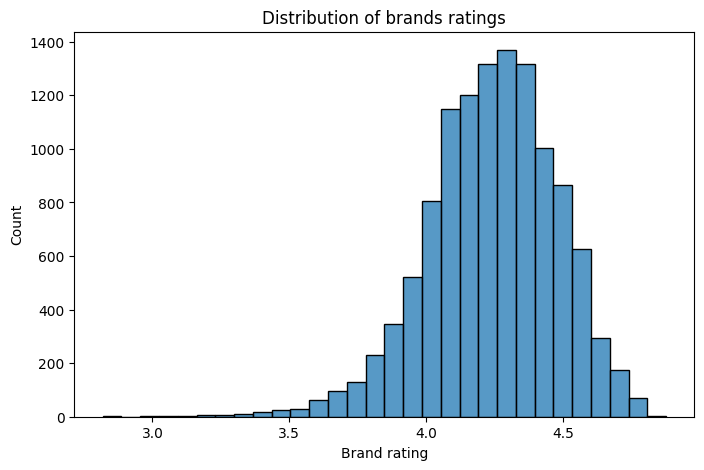

In [3]:
#hist of brands rating distribution
print("Number of brands:", len(brand_stats))
print("Average brand rating:", brand_stats["brand_weighted_score"].mean())
print("Median brand rating:", brand_stats["brand_weighted_score"].median())
plt.figure(figsize=(8,5))
sns.histplot(brand_stats["brand_weighted_score"],bins=30,kde=False)
plt.xlabel("Brand rating")
plt.ylabel("Count")
plt.title("Distribution of brands ratings")
plt.show()

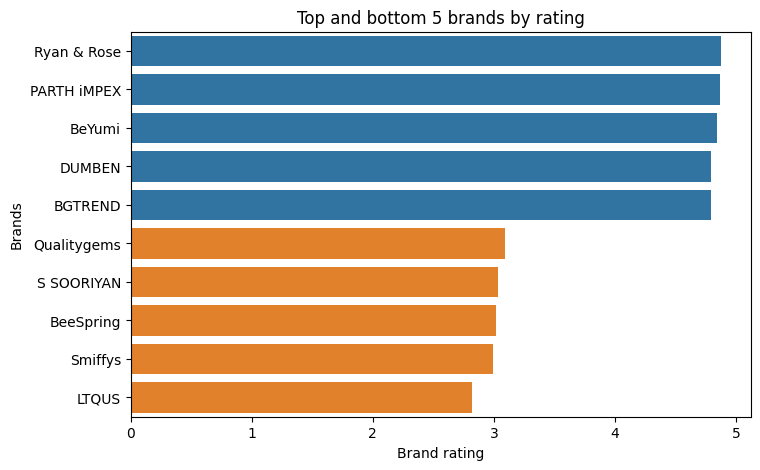

In [4]:
#show top and bottom 5 brands
top5 = brand_stats.head(5)
bottom5=brand_stats.tail(5)
plt.figure(figsize=(8,5))
sns.barplot(data=top5,y="brand",x="brand_weighted_score")
sns.barplot(data=bottom5,y="brand",x="brand_weighted_score")
plt.title("Top and bottom 5 brands by rating")
plt.xlabel("Brand rating")
plt.ylabel("Brands")
plt.show()

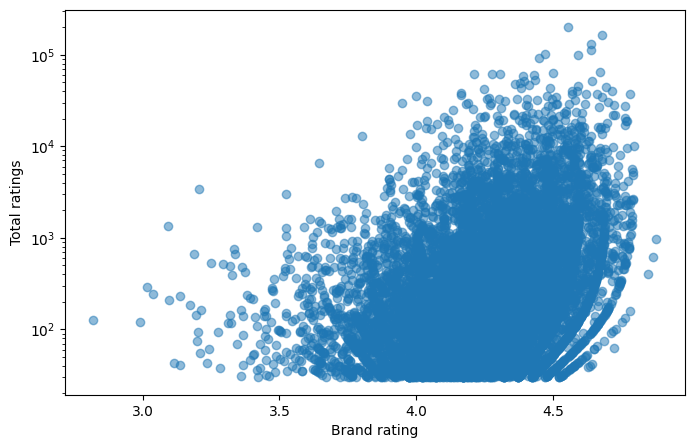

In [5]:
#rating vs # of rating
plt.figure(figsize=(8,5))
plt.scatter(brand_stats["brand_weighted_score"],brand_stats["total_ratings"],alpha=0.5)
plt.yscale("log")
plt.ylabel("Total ratings")
plt.xlabel("Brand rating")
plt.show()

In [7]:
#avg rating per brand per year
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import glob

base_path = Path("/content/drive/MyDrive/Jewelry_Project/Jewelry_review_files/")
year_folders = sorted(base_path.glob("year=*"))

all_products_yearly=[]
for year_folder in year_folders:
    year = int(year_folder.name.split("=")[1])
    parquet_files = list(year_folder.glob("*.parquet"))
    for file in parquet_files:
        df = pd.read_parquet(file,columns=["parent_asin", "brand", "average_rating", "rating_number"])
        df=df.dropna(subset=["parent_asin", "brand", "average_rating", "rating_number"])
        df["brand"] = df["brand"].astype(str).str.strip()
        df["average_rating"] = pd.to_numeric(df["average_rating"], errors="coerce")
        df["rating_number"] = pd.to_numeric(df["rating_number"], errors="coerce")
        df["year"]=year
        df = df.dropna(subset=["average_rating", "rating_number"])
        df = df[df["rating_number"] > 0]
        df = df[(df["average_rating"] >= 0) & (df["average_rating"] <= 5)]
        all_products_yearly.append(df)
products_yearly=pd.concat(all_products_yearly, ignore_index=True)
#but in each for loop / year there are repeated parent asins,
#we have to remove the duplicates again but keep the one with highest rating_number
products_yearly = products_yearly.sort_values(["year", "parent_asin", "rating_number"], ascending=[True, True,False]).drop_duplicates(subset=["year", "parent_asin"], keep="first").reset_index(drop=True)
not_brand = {"", "unknown", "generic", "unbranded", "none", "nan", '/n'}
products_yearly = products_yearly[~products_yearly["brand"].str.lower().isin(not_brand)].copy()
print("total # of unique yearly products:", len(products_yearly))

#bayesian score for each brand based on its products (product bayesian score)
C_products=products_yearly["average_rating"].mean()
product_m = 10 #confidence number (m determines how many ratings are required before we trust the observed rating.)
products_yearly["product_bayesian_score"]=((products_yearly["rating_number"]/(products_yearly["rating_number"]+product_m))*products_yearly["average_rating"])+((product_m/(products_yearly["rating_number"]+product_m))*C_products)
#compute brand performance using product bayesian scores weighted by rating counts. = sum(product bayesian score*rating number)/sum(rating number)
#means:popular products influence the brand more and small products have little influence
products_yearly["weighted_product_score"] = (products_yearly["product_bayesian_score"] * products_yearly["rating_number"]) #weighted score per product
brand_stats_yearly = (products_yearly.groupby(["year","brand"], as_index=False).agg(num_products=("parent_asin", "nunique"), #group products by manufacturer, and count how many unique product each manufacturer has
                                                                           total_ratings=("rating_number", "sum"), #add all the rating number of that manufacturer from all its products
                                                                           weighted_score_sum=("weighted_product_score", "sum"), #add all the weighted values we calculated before
                                                                           simple_mean_product_rating=("average_rating", "mean"))) #avg of avg rating of each product for later comparison
brand_stats_yearly["brand_weighted_score"]= (brand_stats_yearly["weighted_score_sum"] / brand_stats_yearly["total_ratings"])
#remove brand that has less than 10 total rating (from all their products)
min_brand_ratings=10
brand_stats_yearly = brand_stats_yearly[brand_stats_yearly["total_ratings"] >= min_brand_ratings].copy()
brand_stats_yearly = brand_stats_yearly.sort_values(["year", "brand_weighted_score"],ascending=[True,False]).reset_index(drop=True)
# print(brand_stats.head(20))
#rank the brand
brand_stats_yearly["rank_brand"] = (brand_stats_yearly.groupby("year")["brand_weighted_score"].rank(method="first", ascending=False).astype(int))
brand_stats_yearly = brand_stats_yearly[["year", "rank_brand","brand","num_products","total_ratings","brand_weighted_score","simple_mean_product_rating"]].sort_values(["year", "rank_brand"]).reset_index(drop=True)
print(brand_stats_yearly.head(10))
print(brand_stats_yearly.tail(10))
print("What are the high rank brands in 2020?")
brand_stats_2020 = brand_stats_yearly[brand_stats_yearly["year"] == 2020].copy()
print(brand_stats_2020.head(10))
brand_stats_yearly.to_csv("/content/drive/MyDrive/Jewelry_Project/brand_ranking_yearly.csv",index=False)


total # of unique yearly products: 256745
   year  rank_brand              brand  num_products  total_ratings  \
0  2004           1  Amazon Collection             6           31.0   
1  2005           1         Tech Swiss             1          104.0   
2  2005           2         CoolStyles             2           13.0   
3  2005           3  Amazon Collection            14           42.0   
4  2005           4             NOVICA             1          129.0   
5  2005           5    Silver Insanity            13           70.0   
6  2005           6             Hasbro             1           32.0   
7  2005           7         Gem Avenue             1           40.0   
8  2005           8                 SE             1           86.0   
9  2005           9      Huang Acrylic             1           37.0   

   brand_weighted_score  simple_mean_product_rating  
0              3.877396                    3.666667  
1              4.471799                    4.500000  
2             

       year  rank_brand  brand_weighted_score  total_ratings
0      2004           1              3.877396           31.0
3      2005           3              4.121803           42.0
21     2006          11              3.914824           55.0
50     2007          22              4.168448         1256.0
105    2008          27              4.283590         2213.0
211    2009          47              4.254963         4539.0
374    2010          90              4.236335         6936.0
635    2011         127              4.209038         9665.0
1073   2012         225              4.220708        15056.0
1873   2013         428              4.174499        20896.0
2785   2014         358              4.318728        41326.0
4305   2015         511              4.333082        49465.0
6500   2016         744              4.345009        49883.0
9346   2017         922              4.377519        44303.0
13058  2018        1201              4.404426        43633.0
17982  2019        1549 

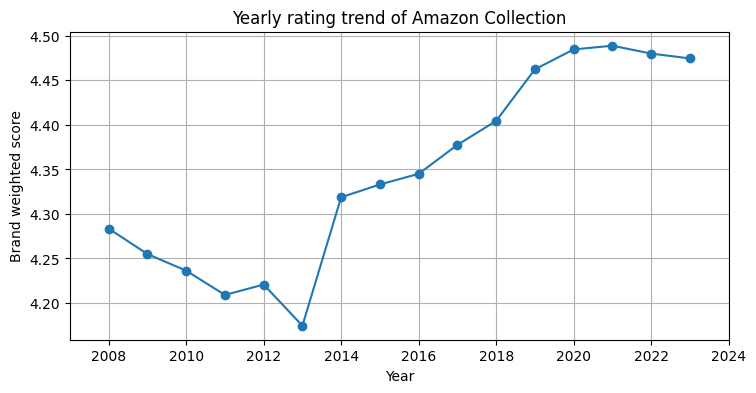

In [15]:
#track how a single brand changes over years
brand_name = "Amazon Collection"
brand_trend = brand_stats_yearly[brand_stats_yearly["brand"].str.lower() == brand_name.lower()].copy()
print(brand_trend[["year", "rank_brand", "brand_weighted_score", "total_ratings"]])
brand_trend=brand_trend[brand_trend["year"]>=2008]
plt.figure(figsize=(8.5,4))
plt.plot(brand_trend["year"], brand_trend["brand_weighted_score"], marker="o")
plt.title(f"Yearly rating trend of {brand_name}")
plt.xlabel("Year")
plt.xlim(2007, 2024)
plt.ylabel("Brand weighted score")
plt.grid(True)
plt.show()

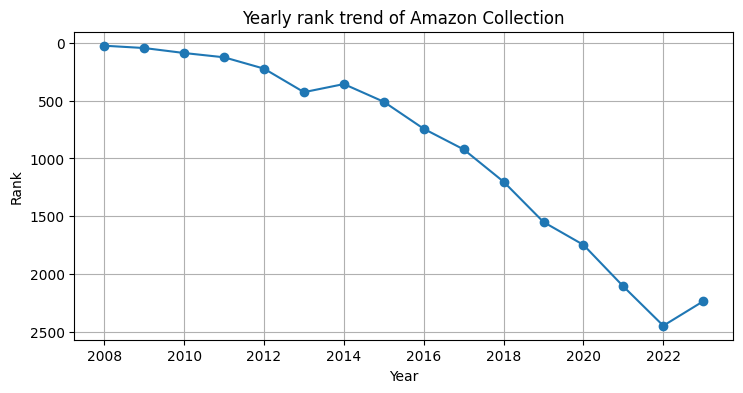

In [16]:
plt.figure(figsize=(8.5,4))
plt.plot(brand_trend["year"], brand_trend["rank_brand"], marker="o")
plt.gca().invert_yaxis()
plt.title(f"Yearly rank trend of {brand_name}")
plt.xlabel("Year")
plt.ylabel("Rank")
plt.grid(True)
plt.show()

count    4.833629e+06
mean     2.816649e+01
std      8.165772e+01
min      1.000000e-02
25%      1.089000e+01
50%      1.499000e+01
75%      2.400000e+01
max      3.322100e+04
dtype: float64


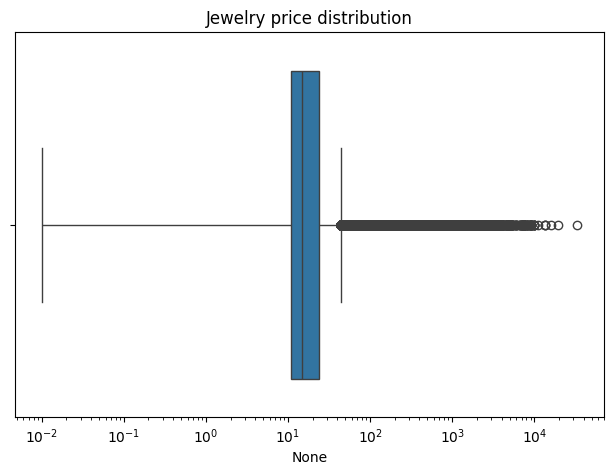

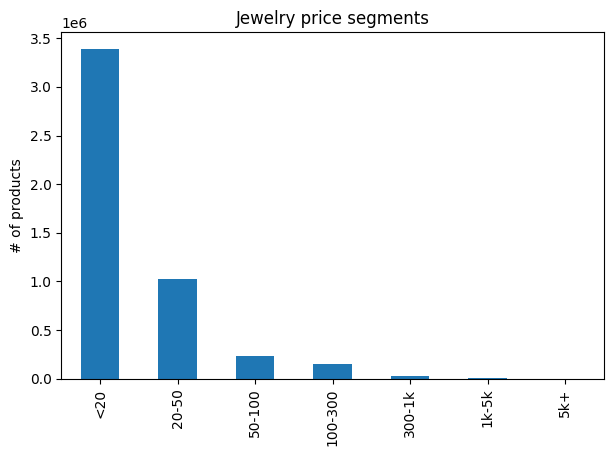

In [28]:
#price dist
#typical price range of jewelry
#luxury vs cheap segments

import pandas as pd
import pathlib as path
import glob
import seaborn as sns

base_path = Path("/content/drive/MyDrive/Jewelry_Project/Jewelry_review_files/")
year_folders = sorted(base_path.glob("year=*"))

price_values=[]
for year_folder in year_folders:
    year = year_folder.name.split("=")[1]
    for file in year_folder.glob("*.parquet"):
        df = pd.read_parquet(file, columns=["parent_asin","brand","price"])
        price_values.extend(df["price"].dropna().values)

price_series = pd.Series(price_values)
print(price_series.describe())


plt.figure(figsize=(7.6,5))
sns.boxplot(x=price_series)
plt.xscale("log")
plt.title("Jewelry price distribution")
plt.show()

plt.figure(figsize=(7,4.5))
bins = [0,20,50,100,300,1000,5000,50000]
labels = ["<20","20-50","50-100","100-300","300-1k","1k-5k","5k+"]
segments = pd.cut(price_series, bins=bins, labels=labels)
segments.value_counts().sort_index().plot(kind="bar")
plt.title("Jewelry price segments")
plt.ylabel("# of products")
plt.show()


# # lower = price_series.quantile(0.01)
# upper = price_series.quantile(0.99)
# sns.histplot(price_series[price_series <= upper], bins=100)
# plt.title("Price distribution")
# # plt.xlim(lower, upper)
# plt.show()


In [29]:
#segmenting data based on the price
import pandas as pd
from pathlib import Path
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

base_path = Path("/content/drive/MyDrive/Jewelry_Project/Jewelry_review_files/")
year_folders = sorted(base_path.glob("year=*"))
brand_ranking_csv_path = Path("/content/drive/MyDrive/Jewelry_Project/brand_ranking.csv")
brand_ranking_yearly_csv_path = Path("/content/drive/MyDrive/Jewelry_Project/brand_ranking_yearly.csv")

all_product_prices=[]
not_brand = {"", "unknown", "generic", "unbranded", "none", "nan", "/n"}
for year_folder in year_folders:
    year = int(year_folder.name.split("=")[1])
    for file in year_folder.glob("*.parquet"):
        df = pd.read_parquet(file, columns=["parent_asin","asin", "brand","price"])
        df = df.dropna(subset=["parent_asin", "asin", "brand", "price"])
        df["year"]= year
        df["brand"] = df["brand"].astype(str).str.strip()
        df["price"] = pd.to_numeric(df["price"], errors="coerce")
        df = df[df["price"] > 0] #keep logical prices
        df = df[~df["brand"].str.lower().isin(not_brand)] #remove not brand
        df = df.drop_duplicates(subset=["asin"]) #keep only one product row and remove the rest in this loop
        #asin is used because one single product can have for instance 4 different colors, each with different prices
        all_product_prices.append(df)

products_price=pd.concat(all_product_prices, ignore_index=True)
products_price=(products_price.sort_values(["parent_asin","price"],ascending=[True,False]).drop_duplicates(subset=["asin"], keep="first").reset_index(drop=True))
# products_price["price_segment"] = pd.qcut(products_price["price"],q=3,labels=["cheap","mid","expensive"])
products_price["price_segment"] = np.select([products_price["price"] < 100,(products_price["price"] >= 100) & (products_price["price"] <= 1000),products_price["price"] > 1000],["cheap", "mid", "luxury"],default="unknown")
products_price["price_segment"].value_counts()


,count
price_segment,
cheap,108838
mid,5769
luxury,300


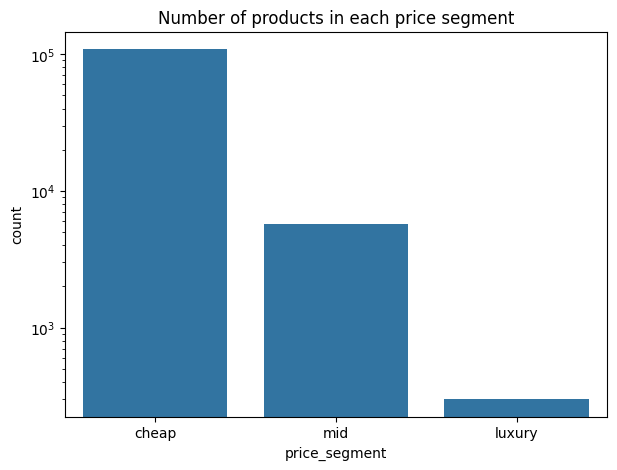

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=products_price, x="price_segment",order=["cheap","mid","luxury"])
plt.title("Number of products in each price segment")
plt.yscale('log')
plt.show()

In [ ]:
# plt.figure(figsize=(8,5))
# sns.histplot(products_price["price"], bins=100)
# plt.axvline(100, color="orange", linestyle="--", label="cheap/mid")
# plt.axvline(1000, color="red", linestyle="--", label="mid/luxury")
# plt.xscale("log")
# plt.yscale('log')
# plt.title("Jewelry price distribution with segment thresholds")
# plt.legend()
# plt.show()

In [ ]:
# brand_price_year = (products_price.groupby(["brand","year"], as_index=False).agg(num_products=("parent_asin","nunique"),min_price=("price","min"),max_price=("price","max"),avg_price=("price","mean"),median_price=("price","median"),std_price=("price","std")))
# brand_price_year["std_price"] = brand_price_year["std_price"].fillna(0)
# print(brand_price_year.head())
# segment_stats = (products_price.groupby(["year","price_segment"]).agg(med_price=("price","median"),num_products=("asin","count")).reset_index())
# #time evolution of prices
# print("Does jewelry price increase over time?")
# plt.figure(figsize=(10,6))
# sns.lineplot(data=segment_stats,x="year",y="med_price",hue="price_segment")
# plt.title("Price evolution of jewelry segments")
# plt.yscale("log")
# plt.xlim(2004, 2025)
# plt.xticks(np.arange(2004, 2025, 1), rotation=45)
# plt.ylabel("Median price")
# plt.xlabel("Year")
# plt.show()

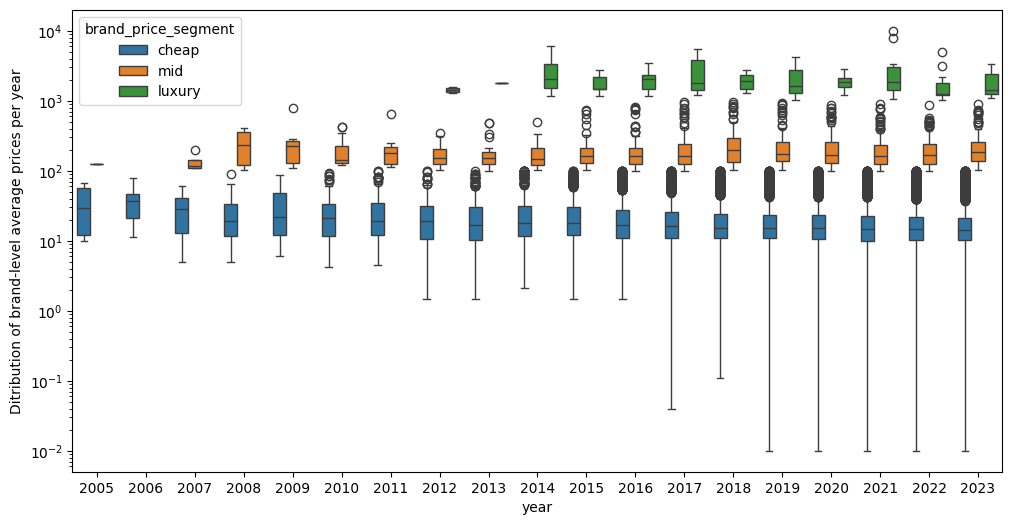

In [33]:
brand_price_year = (products_price.groupby(["brand","year"], as_index=False).agg(num_products=("parent_asin","nunique"),min_price=("price","min"),max_price=("price","max"),avg_price=("price","mean"),median_price=("price","median"),std_price=("price","std")))
brand_price_year["std_price"] = brand_price_year["std_price"].fillna(0)
brand_price_year["brand_price_segment"] = np.select([brand_price_year["avg_price"] < 100,(brand_price_year["avg_price"] >= 100) & (brand_price_year["avg_price"] <= 1000),brand_price_year["avg_price"] > 1000],["cheap", "mid", "luxury"],default="unknown")

plt.figure(figsize=(12,6))
sns.boxplot(data=brand_price_year,x="year",y="avg_price",hue="brand_price_segment")
plt.yscale('log')
plt.ylabel('Ditribution of brand-level average prices per year')
plt.show()

Are luxury brands overrated or underrated?


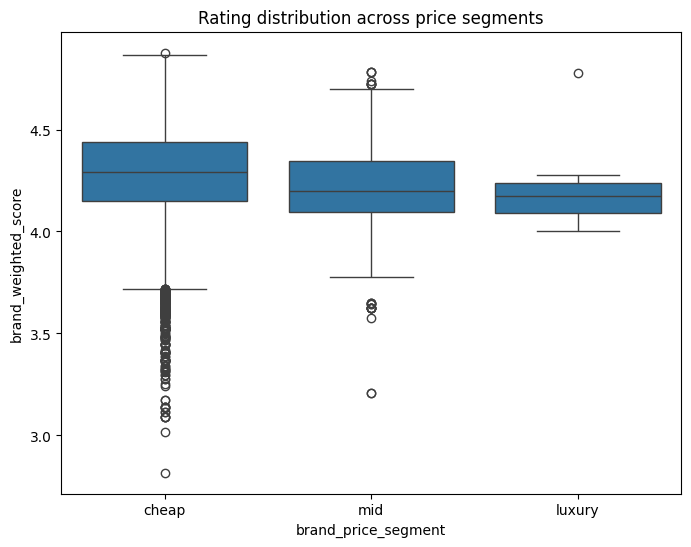

In [34]:
brand_ranking = pd.read_csv(brand_ranking_csv_path)
brand_ranking["brand"] = brand_ranking["brand"].astype(str).str.strip()
brand_analysis=pd.merge(brand_price_year, brand_ranking[["brand", "rank_brand", "brand_weighted_score", "total_ratings"]], on="brand", how="left")
brand_analysis.head(5)
brand_analysis["brand_price_segment"] = np.select([brand_analysis["avg_price"] < 100,(brand_analysis["avg_price"] >= 100) & (brand_analysis["avg_price"] <= 1000),brand_analysis["avg_price"] > 1000],["cheap", "mid", "luxury"],default="unknown")
print("Are luxury brands overrated or underrated?")
#compare rating vs price segment
plt.figure(figsize=(8,6))
sns.boxplot(data=brand_analysis,x="brand_price_segment",y="brand_weighted_score",order=["cheap","mid","luxury"])
plt.title("Rating distribution across price segments")
plt.show()

                                               brand  year  num_products  \
0                                                 01  2020             2   
1                                                 01  2021             1   
2                                                 01  2022             1   
3  1.80-2.44 Cts of 7x5 mm AAA Emerald Peridot ( ...  2014             1   
4                                        1000 Jewels  2015             1   

   min_price  max_price  avg_price  median_price  std_price  \
0      18.90      49.99     34.445        34.445   21.98395   
1      18.90      18.90     18.900        18.900    0.00000   
2      27.23      27.23     27.230        27.230    0.00000   
3      14.15      14.15     14.150        14.150    0.00000   
4      41.00      41.00     41.000        41.000    0.00000   

  brand_price_segment  rank_brand  brand_weighted_score  total_ratings  
0               cheap      1193.0               4.54313          220.0  
1               ch

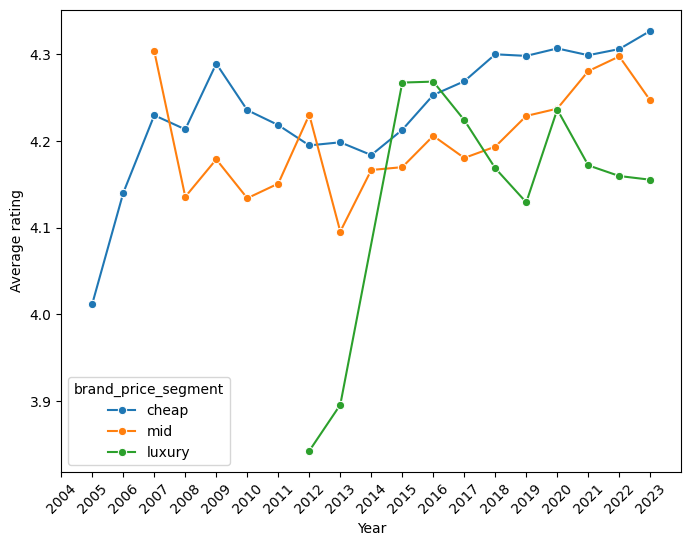

In [36]:
brand_ranking_yearly = pd.read_csv(brand_ranking_yearly_csv_path)
brand_ranking_yearly["brand"] = brand_ranking_yearly["brand"].astype(str).str.strip()
brand_analysis_yearly = pd.merge(brand_price_year,brand_ranking_yearly[["year", "brand", "rank_brand", "brand_weighted_score", "total_ratings"]],on=["year", "brand"],how="left")
print(brand_analysis_yearly.head(5))
brand_analysis_yearly["brand_price_segment"] = np.select([brand_analysis_yearly["avg_price"] < 100,(brand_analysis_yearly["avg_price"] >= 100) & (brand_analysis_yearly["avg_price"] <= 1000),brand_analysis_yearly["avg_price"] > 1000],["cheap", "mid", "luxury"],default="unknown")
print("Do expensive jewelry brands have better ratings?")
# average brand rating for each price segment in each year
rating_segment_year = (brand_analysis_yearly.dropna(subset=["brand_weighted_score"]).groupby(["year", "brand_price_segment"], as_index=False).agg(avg_rating=("brand_weighted_score", "mean"),median_rating=("brand_weighted_score", "median"),num_brands=("brand", "nunique")))
print(rating_segment_year.head())
plt.figure(figsize=(8,6))
sns.lineplot(data=rating_segment_year,x="year",y="avg_rating",hue="brand_price_segment",marker="o")
plt.ylabel("Average rating")
plt.xlim(2004,2024)
plt.xticks(np.arange(2004, 2024, 1), rotation=45)
plt.xlabel("Year")
plt.show()

Are cheap brands more popular?


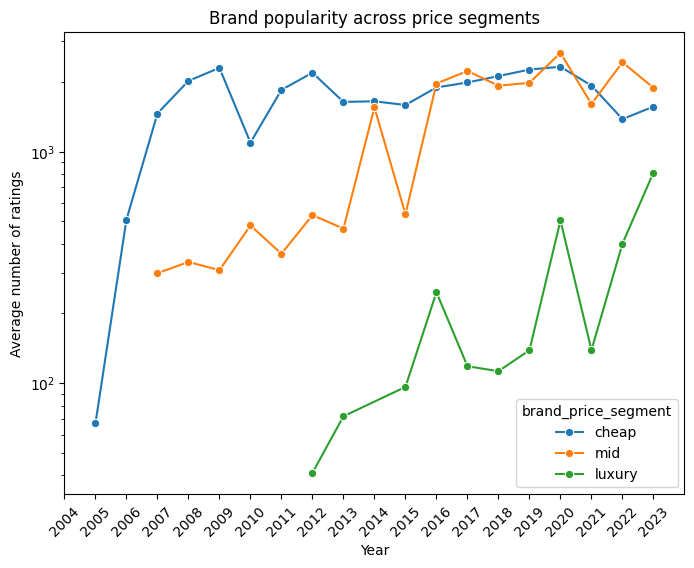

In [37]:
print("Are cheap brands more popular?")
# total_ratings / num_brands
popularity_segment_year = (brand_analysis_yearly.groupby(["year","brand_price_segment"]).agg(avg_ratings=("total_ratings","mean")).reset_index())
plt.figure(figsize=(8,6))
sns.lineplot(data=popularity_segment_year,x="year",y="avg_ratings",hue="brand_price_segment",marker="o")
plt.yscale("log")
plt.xlim(2004,2024)
plt.xticks(np.arange(2004, 2024, 1), rotation=45)
plt.title("Brand popularity across price segments")
plt.ylabel("Average number of ratings")
plt.xlabel("Year")
plt.show()

Which brands are best value for money? specifically at year 2023 (the most recent data)
              brand  brand_weighted_score  avg_price  value_score
22530  Tennessee526              3.501695   0.320000    12.612731
10709       Ink2055              4.220052   0.450000    11.357550
15777     MileHouse              4.080248   0.577273     8.953856
               brand  brand_weighted_score  avg_price  value_score
3631   CASE ELEGANCE              4.742243     109.99     1.006965
13440       LUXFURNI              4.647096     117.99     0.972391
25383       YOKUKINA              4.662770     124.99     0.964139
                          brand  brand_weighted_score  avg_price  value_score
13509            La4ve Diamonds              4.199784   1413.740     0.578905
11798                John Hardy              3.999290   1095.000     0.571374
10224  Houston Diamond District              4.266915   3346.575     0.525742


/tmp/ipykernel_16960/2082127835.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brand_value_2023["value_score"] = (brand_value_2023["brand_weighted_score"]/np.log(brand_value_2023["avg_price"] + 1))


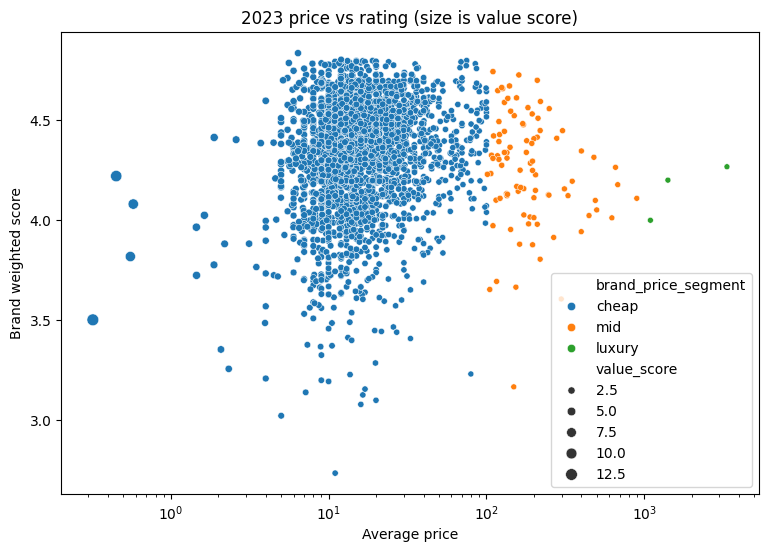

/tmp/ipykernel_16960/2082127835.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  brand_value = brand_value.groupby(["year", "brand_price_segment"], group_keys=False).apply(compute_z)


                        brand  brand_weighted_score  avg_price  z_rating  \
23766  VILLAGE GIFT IMPORTERS              4.834592       6.39  1.924126   
20926             ShiQiao Spl              4.785478       5.59  1.737957   
4437                Charmount              4.782038       7.89  1.724915   

        z_price  value_score_z  
23766 -0.844318       2.768444  
20926 -0.898342       2.636298  
4437  -0.743024       2.467939  
               brand  brand_weighted_score  avg_price  z_rating   z_price  \
3631   CASE ELEGANCE              4.742243     109.99  1.771898 -0.794956   
25383       YOKUKINA              4.662770     124.99  1.487714 -0.696534   
16833       Nicetree              4.725500     160.49  1.712028 -0.463604   

       value_score_z  
3631        2.566854  
25383       2.184248  
16833       2.175633  
                          brand  brand_weighted_score  avg_price  z_rating  \
13509            La4ve Diamonds              4.199784   1413.740  0.391015   
10224 

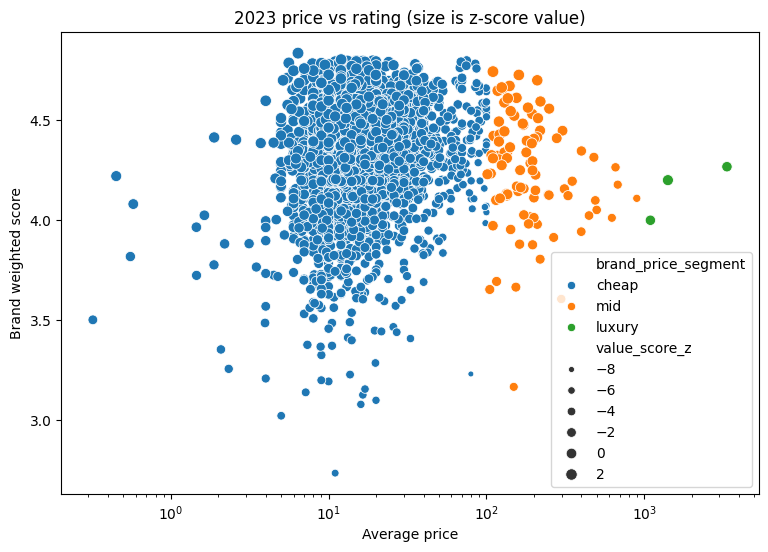

In [38]:
print("Which brands are best value for money? specifically at year 2023 (the most recent data)")
#compare price vs rating (ratig/log(price)) [cheap + high rating is the best]
brand_value = brand_analysis_yearly.copy()
brand_value["brand_price_segment"] = np.select([brand_value["avg_price"] < 100,(brand_value["avg_price"] >= 100) & (brand_value["avg_price"] <= 1000),brand_value["avg_price"] > 1000],["cheap", "mid", "luxury"],default="unknown")
brand_value_2023 = brand_value[brand_value["year"] == 2023]
brand_value_2023["value_score"] = (brand_value_2023["brand_weighted_score"]/np.log(brand_value_2023["avg_price"] + 1))
top3_per_segment = (brand_value_2023.sort_values(["brand_price_segment", "value_score"], ascending=[True, False]).groupby("brand_price_segment").head(3)[["brand_price_segment", "brand", "brand_weighted_score", "avg_price", "value_score"]].reset_index(drop=True))
for seg in ["cheap", "mid", "luxury"]:
    print(brand_value_2023[brand_value_2023["brand_price_segment"] == seg]
          .sort_values("value_score", ascending=False)[["brand", "brand_weighted_score", "avg_price", "value_score"]].head(3))
plt.figure(figsize=(9,6))
sns.scatterplot(data=brand_value_2023,x="avg_price",y="brand_weighted_score",size="value_score",hue="brand_price_segment")
plt.xscale("log")
plt.title("2023 price vs rating (size is value score)")
plt.xlabel("Average price")
plt.ylabel("Brand weighted score")
plt.show()

#so a brand gets a high score if:
#rating is high relative to peers
#price is low relative to peers

def compute_z(group):
    group = group.copy()

    rating_mean = group["brand_weighted_score"].mean()
    rating_std = group["brand_weighted_score"].std(ddof=0)

    price_mean = group["avg_price"].mean()
    price_std = group["avg_price"].std(ddof=0)

    group["z_rating"] = 0 if rating_std == 0 else (group["brand_weighted_score"] - rating_mean) / rating_std
    group["z_price"]  = 0 if price_std == 0 else (group["avg_price"] - price_mean) / price_std

    group["value_score_z"] = group["z_rating"] - group["z_price"]
    return group

brand_value = brand_value.groupby(["year", "brand_price_segment"], group_keys=False).apply(compute_z)
brand_value_2023 = brand_value[brand_value["year"] == 2023].copy()
top3_z_per_segment = (brand_value_2023.sort_values(["brand_price_segment", "value_score_z"], ascending=[True, False]).groupby("brand_price_segment").head(3)[["brand_price_segment", "brand", "brand_weighted_score", "avg_price", "z_rating", "z_price", "value_score_z"]].reset_index(drop=True))
for seg in ["cheap", "mid", "luxury"]:
    print(brand_value_2023[brand_value_2023["brand_price_segment"] == seg]
          .sort_values("value_score_z", ascending=False)[["brand", "brand_weighted_score", "avg_price", "z_rating", "z_price", "value_score_z"]].head(3))

plt.figure(figsize=(9,6))
sns.scatterplot(data=brand_value_2023,x="avg_price",y="brand_weighted_score", size="value_score_z",hue="brand_price_segment")
plt.xscale("log")
plt.title("2023 price vs rating (size is z-score value)")
plt.xlabel("Average price")
plt.ylabel("Brand weighted score")
plt.show()

Does price increase over time within the same brand? The best rank brands in 2023 is chosen to check their price evolution


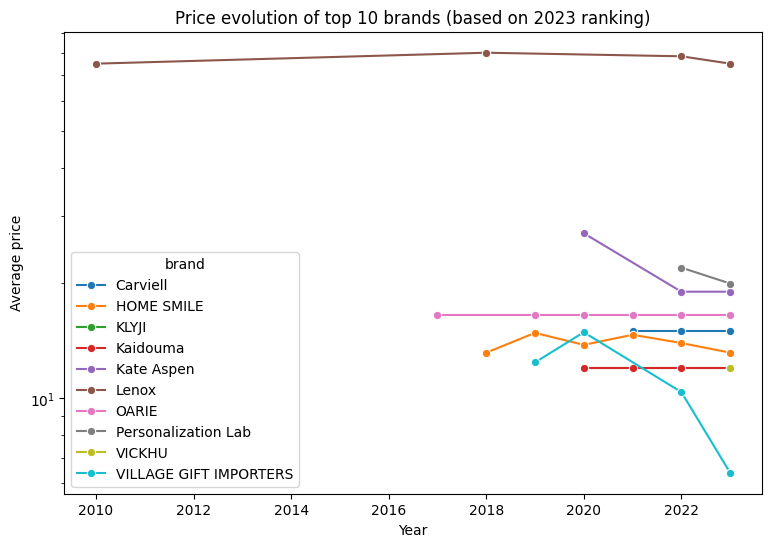

In [46]:
print("Does price increase over time within the same brand? The best rank brands in 2023 is chosen to check their price evolution")
#compare price vs rating
top10_brands_2023 = (brand_analysis_yearly[brand_analysis_yearly["year"]==2023].sort_values("rank_brand")[["brand", "rank_brand"]].head(10))
# print(top10_brands_2023)
top10_brand_names = top10_brands_2023["brand"]
top10_trend = (brand_analysis_yearly[brand_analysis_yearly["brand"].isin(top10_brand_names)].sort_values(["brand", "year"]).copy())
top10_trend = top10_trend.merge(top10_brands_2023,on="brand",how="left") #merging to have labels
# top10_trend["brand_label"] = (top10_trend["brand"] + " (Rank " + top10_trend["rank_brand_x"].astype(int).astype(str) + ")")
plt.figure(figsize=(9,6))
sns.lineplot(data=top10_trend,x="year",y="avg_price",hue="brand",marker="o")
plt.yscale("log")
plt.title("Price evolution of top 10 brands (based on 2023 ranking)")
plt.xlabel("Year")
plt.ylabel("Average price")
plt.show()

How the jewelry market evolved on Amazon


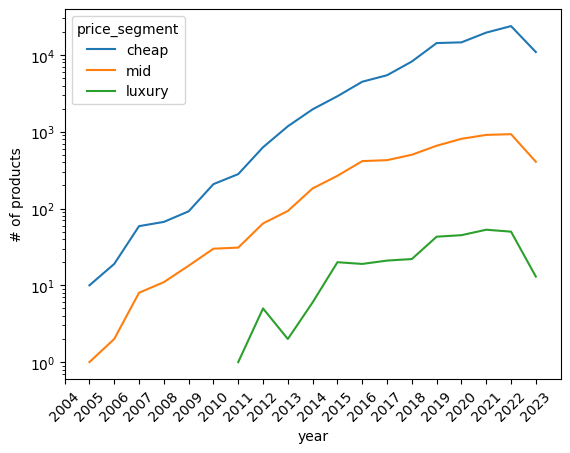

In [42]:
print("How the jewelry market evolved on Amazon")
# # of products per segment (is Amazon jewelry becoming more luxury over time?)
segment_counts = (products_price.groupby(["year","price_segment"]).size().reset_index(name="num_products"))
sns.lineplot(data=segment_counts,x="year",y="num_products",hue="price_segment")
plt.ylabel('# of products')
plt.yscale('log')
plt.xlim(2004,2024)
plt.xticks(np.arange(2004, 2024, 1), rotation=45)
plt.show()

In [45]:
# print("Which brands have unstable pricing?")
print('how much the brand’s average price changes over time?')
price_change = (brand_analysis_yearly.groupby(["brand", "brand_price_segment"])["avg_price"].std().reset_index(name="price_change").sort_values("price_change", ascending=False))
print(price_change.head(20))

how much the brand’s average price changes over time?
                                     brand brand_price_segment  price_change
2634                          Diamond Wish              luxury   2250.477279
3387                        Fashion Strada              luxury   1899.288814
10649                      VIP Jewelry Art              luxury   1414.213562
6783                        Madina Jewelry              luxury   1201.388086
7846                           P3 POMPEII3              luxury   1159.196112
4630              Houston Diamond District              luxury    691.449040
10651                           VIR JEWELS              luxury    486.769396
10338                            TriJewels              luxury    374.703779
9230                      Saris and Things                 mid    315.122686
10652                           VIR JEWELS                 mid    314.483884
1289                        Better Jewelry                 mid    309.001589
9841                  

total # of unique products: 571957
total # of unique products after cleaning not manufacturers: 570018
   rank               manufacturer  num_products  total_ratings  \
0     1  dogtags4less - Cyber Zone             1         1069.0   
1     2                PARTH IMPEX             1          616.0   
2     3                     DISNEY             3          417.0   
3     4             Apotie factory             1          223.0   
4     5                    TAWBURY             8         1271.0   
5     6                      Yiama             1         8917.0   
6     7                Groundspeak             1          192.0   
7     8                 JD Jewelry             1         3955.0   
8     9              shining image             2         4089.0   
9    10                    BGTREND             1         2673.0   

   manufacturer_weighted_score  simple_mean_product_rating  
0                     4.878855                    4.900000  
1                     4.864027       

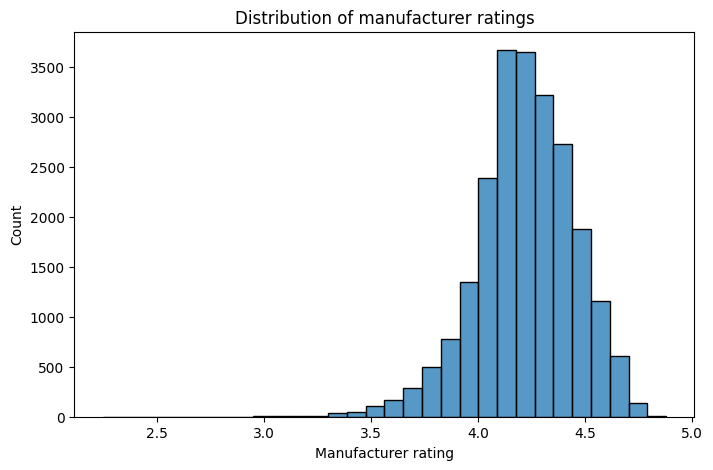

Number of manufacturers: 22763
Average manufacturer rating: 4.217932870850834
Median manufacturer rating: 4.222775468181671


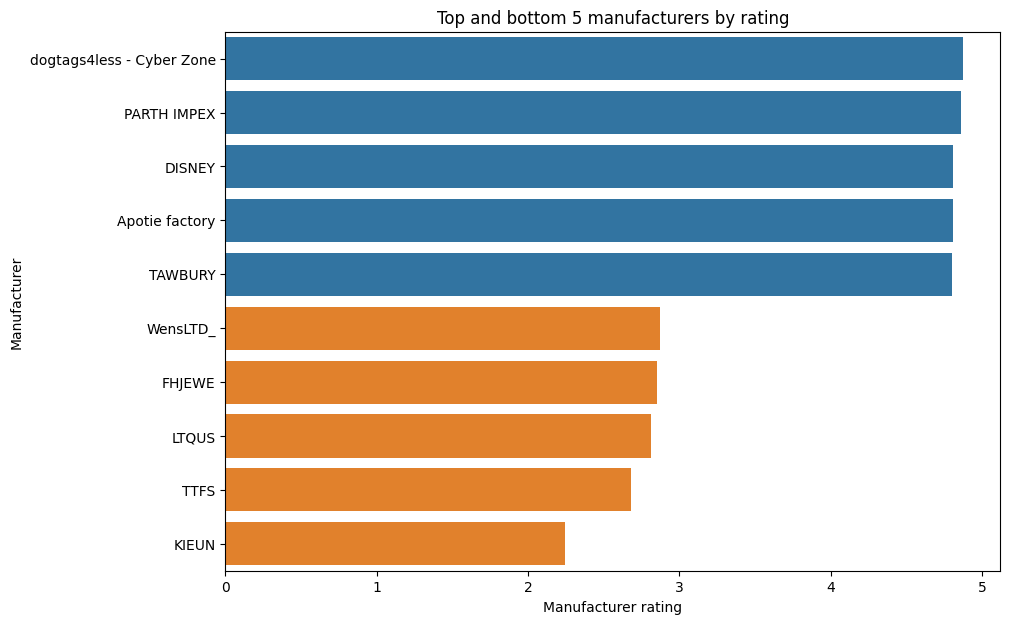

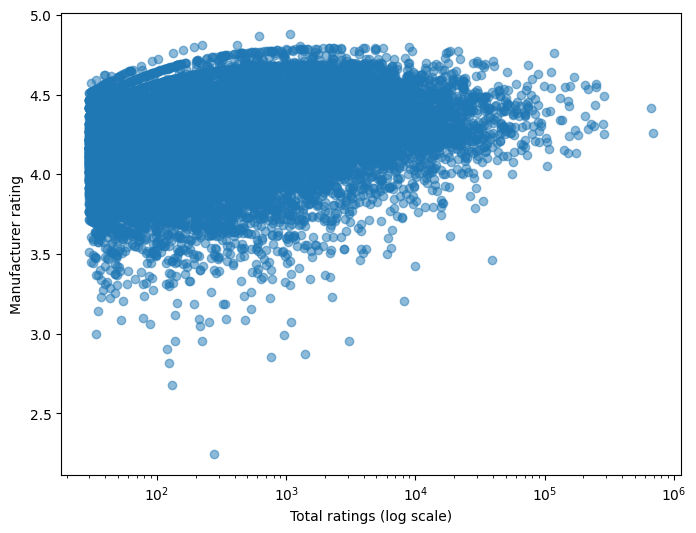

In [44]:
#avg rating per manufacurer - it is a repitition of the code above for brands to see how is the situation with the manufacturers
#note1: clean data, keep one row for each product, remove not existed manufacturers
#note2: bayesian score at the level of each manufacurer based on its products
#note3: computing manufacturer performance
#note4: neglect manufacturer that their total rating number is less than 30
#note5: rank manufacturers
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import glob

base_path = Path("/content/drive/MyDrive/Jewelry_Project/Jewelry_review_files/")
year_folders = sorted(base_path.glob("year=*"))

all_products=[]
for year_folder in year_folders:
    year = year_folder.name.split("=")[1]
    parquet_files = list(year_folder.glob("*.parquet"))
    for file in parquet_files:
        df = pd.read_parquet(file,columns=["parent_asin", "manufacturer", "average_rating", "rating_number"])
        df=df.dropna(subset=["parent_asin", "manufacturer", "average_rating", "rating_number"])
        df["manufacturer"] = df["manufacturer"].astype(str).str.strip()
        df["average_rating"] = pd.to_numeric(df["average_rating"], errors="coerce")
        df["rating_number"] = pd.to_numeric(df["rating_number"], errors="coerce")
        #to keep only valid values
        df = df.dropna(subset=["average_rating", "rating_number"])
        df = df[df["rating_number"] > 0]
        df = df[(df["average_rating"] >= 0) & (df["average_rating"] <= 5)]
        #to keep only one row for each product
        # df = df.drop_duplicates(subset=["parent_asin"]) #removing duplicate parent asin in this loop only
        all_products.append(df)
products=pd.concat(all_products, ignore_index=True)
# print(products)
#but in each for loop / year there are repeated parent asins,
#we have to remove the duplicates again but keep the one with highest rating_number
products = products.sort_values(["parent_asin", "rating_number"], ascending=[True,False]).drop_duplicates(subset=["parent_asin"], keep="first").reset_index(drop=True)
print("total # of unique products:", len(products))
not_manufacturers = {"", "unknown", "generic", "unbranded", "none", "nan"}
products = products[~products["manufacturer"].str.lower().isin(not_manufacturers)].copy()
print("total # of unique products after cleaning not manufacturers:", len(products))

#bayesian score for each manufacturer based on its products (product bayesian score)
C_products=products["average_rating"].mean()
product_m = 30 #confidence number (m determines how many ratings are required before we trust the observed rating.)
products["product_bayesian_score"]=((products["rating_number"]/(products["rating_number"]+product_m))*products["average_rating"])+((product_m/(products["rating_number"]+product_m))*C_products)
#compute manufacturer performance using product bayesian scores weighted by rating counts. = sum(product bayesian score*rating number)/sum(rating number)
#means:popular products influence the manufacturer more and small products have little influence
products["weighted_product_score"] = (products["product_bayesian_score"] * products["rating_number"]) #weighted score per product
manufacturer_stats = (products.groupby("manufacturer", as_index=False).agg(num_products=("parent_asin", "nunique"), #group products by manufacturer, and count how many unique product each manufacturer has
                                                                           total_ratings=("rating_number", "sum"), #add all the rating number of that manufacturer from all its products
                                                                           weighted_score_sum=("weighted_product_score", "sum"), #add all the weighted values we calculated before
                                                                           simple_mean_product_rating=("average_rating", "mean"))) #avg of avg rating of each product for later comparison
manufacturer_stats["manufacturer_weighted_score"]= (manufacturer_stats["weighted_score_sum"] / manufacturer_stats["total_ratings"])
#remove manufacturer that has less than 30 total rating (from all their products)
min_manufacturer_ratings=30
manufacturer_stats = manufacturer_stats[manufacturer_stats["total_ratings"] >= min_manufacturer_ratings].copy()

manufacturer_stats = manufacturer_stats.sort_values("manufacturer_weighted_score",ascending=False).reset_index(drop=True)
# print(manufacturer_stats.head(20))
#rank the manufacturers
manufacturer_stats["rank"] = np.arange(1, len(manufacturer_stats)+1)
manufacturer_stats = manufacturer_stats[["rank","manufacturer","num_products","total_ratings","manufacturer_weighted_score","simple_mean_product_rating"]]
print(manufacturer_stats.head(10))
print(manufacturer_stats.tail(10))
manufacturer_stats.to_csv("/content/drive/MyDrive/Jewelry_Project/manufacturer_ranking.csv",index=False)

#hist of manufacturer rating distribution
plt.figure(figsize=(8,5))
sns.histplot(manufacturer_stats["manufacturer_weighted_score"],bins=30,kde=False)
plt.xlabel("Manufacturer rating")
plt.ylabel("Count")
plt.title("Distribution of manufacturer ratings")
plt.show()
print("Number of manufacturers:", len(manufacturer_stats))
print("Average manufacturer rating:", manufacturer_stats["manufacturer_weighted_score"].mean())
print("Median manufacturer rating:", manufacturer_stats["manufacturer_weighted_score"].median())

#top and bottom 5 manufacturer
top5 = manufacturer_stats.head(5)
bottom5=manufacturer_stats.tail(5)
plt.figure(figsize=(10,7))
sns.barplot(data=top5,y="manufacturer",x="manufacturer_weighted_score")
sns.barplot(data=bottom5,y="manufacturer",x="manufacturer_weighted_score")
plt.title("Top and bottom 5 manufacturers by rating")
plt.xlabel("Manufacturer rating")
plt.ylabel("Manufacturer")
plt.show()

#rating vs # of rating
plt.figure(figsize=(8,6))
plt.scatter(manufacturer_stats["total_ratings"],manufacturer_stats["manufacturer_weighted_score"],alpha=0.5)
plt.xscale("log")
plt.xlabel("Total ratings (log scale)")
plt.ylabel("Manufacturer rating")
plt.show()
